# Entregável 3 — Análise Estatística Inicial da Base

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Objetivo

Este notebook descreve a etapa de **Análise Estatística** do dataset. No entregável 1, já foi feita uma análise exploratória e descritiva básica que permitiu entender o que existe no dataset. A estatística lá tinha como foco a caracterização; responder à pergunta: "o que eu tenho nas mãos?". Agora, no entregável 3, essa análise será inferencial/metodológica, ou seja, servirá como base para decisões futuras, procurando qualificar estatisticamente os dados e definir a metodologia analítica para o restante do projeto. Por isso, terá como foco responder à pergunta: "quais são os pressupostos dos meus dados e que ferramentas posso usar?". Sendo assim, este notebook é composto pelas seguintes seções:

1. **Estatística Descritiva dos Metadados:** Distribuição das variáveis demográficas (idade, peso, altura) para o dataset completo e estratificadas por superclasse diagnóstica; análise da evolução temporal das coletas.
2. **Estatística Descritiva dos Sinais:** Métricas de amplitude (RMS e pico a pico) e energia total calculadas por derivação e por superclasse, com base em amostra estratificada.
3. **Testes de Normalidade:** Shapiro-Wilk e Kolmogorov-Smirnov para verificação do pressuposto de distribuição normal; Q-Q Plots para inspeção visual.
4. **Testes de Homocedasticidade:** Levene e Bartlett para verificação de igualdade de variâncias entre grupos diagnósticos.
5. **Análise de Correlação:** Matrizes de correlação de Pearson e Spearman entre variáveis demográficas, métricas do sinal e SQI.
6. **Síntese e Conexão:** Tabela-decisão metodológica e conexão com os entregáveis seguintes.

## 1. Importações, Configurações e Dependências

Neste entregável, utilizamos as mesmas bibliotecas já utilizadas nos entregáveis anteriores, sem nenhuma adição.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats       
from pathlib import Path              
from tqdm import tqdm
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

Aqui são definidas as constantes globais do projeto, que já foram definidas e justificadas nos entregáveis anteriores.

In [2]:
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/')
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em : {FIGS_DIR.resolve()}')
print(f'Outputs em : {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-3\figuras
Outputs em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-3\outputs


## 3. Carregamento e Filtragem Inicial

Aqui, partimos do arquivo `ptbxl_com_sqi.csv` gerado pelo Entregável 2, que já contém todas as colunas do Entregável 1 (metadados enriquecidos, superclasses diagnósticas, ritmos, formas, splits) acrescidas das métricas SQI e da classificação de qualidade (`quality_class`: A, G, P ou U).

O primeiro passo é **remover os registros de Categoria U** — aqueles identificados como de baixa qualidade irrecuperável pelo sistema de avaliação SQI implementado no Entregável 2. Manter esses registros na análise introduziria viés estatístico, pois suas métricas de amplitude e morfologia são contaminadas por ruído ou artefatos e não representam a atividade cardíaca real.

Algumas colunas foram serializadas como strings no CSV (listas e dicionários Python); é necessário fazer o parse correto com `ast.literal_eval` antes de usá-las.

In [3]:
caminho_metadados = '../../entregavel-2/outputs/ptbxl_com_sqi.csv'

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError(
        f"Arquivo ptbxl_com_sqi.csv não encontrado em: {caminho_metadados}\n"
        "Execute o Entregável 2 primeiro."
    )

df = pd.read_csv(caminho_metadados, index_col='ecg_id')

# Reconversão de colunas serializadas como string
df['scp_codes']        = df['scp_codes'].apply(ast.literal_eval)
df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)  # nome correto do Entregável 1
df['recording_date']   = pd.to_datetime(df['recording_date'], errors='coerce')

tam_original = len(df)
df = df[df['quality_class'].isin(['A', 'G', 'P'])].copy()

# Remove colunas que foram auxiliares na análise final do Entregável 2, mas agora não mais são úteis
df = df.drop(columns=['is_good', 'is_bad'], errors='ignore')

display(Markdown(
    f"Dataset carregado do Entregável 2.  \n"
    f"Removidos **{tam_original - len(df)}** registros de Categoria U (Unacceptable).  \n"
    f"Trabalhando com **{len(df)}** registros aprovados (categorias G, A e P)."
))

Dataset carregado do Entregável 2.  
Removidos **1959** registros de Categoria U (Unacceptable).  
Trabalhando com **19840** registros aprovados (categorias G, A e P).

---

## Seção 1 — Estatística Descritiva dos Metadados

### 1.1 Variáveis Demográficas

Antes de qualquer teste inferencial, vamos rever algumas variáveis demográficas (Idade, peso e altura) que já foram vistas no entregável 1, a fim de analisar como está o comportamento do dataset após remover os dados de classe U e também para reafirmar os resultados adquiridos e tirar novas conclusões a partir disso.

**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**

,count,mean,std,min,5%,25%,75%,95%,max,IQR,Variância
age_clean,19581.0,59.71,16.65,3.0,27.0,50.0,72.0,84.0,89.0,22.0,277.10
weight,8345.0,70.98,15.78,5.0,50.0,60.0,80.0,96.0,250.0,20.0,249.14
height,6188.0,166.66,10.84,6.0,152.0,160.0,174.0,183.0,209.0,14.0,117.53


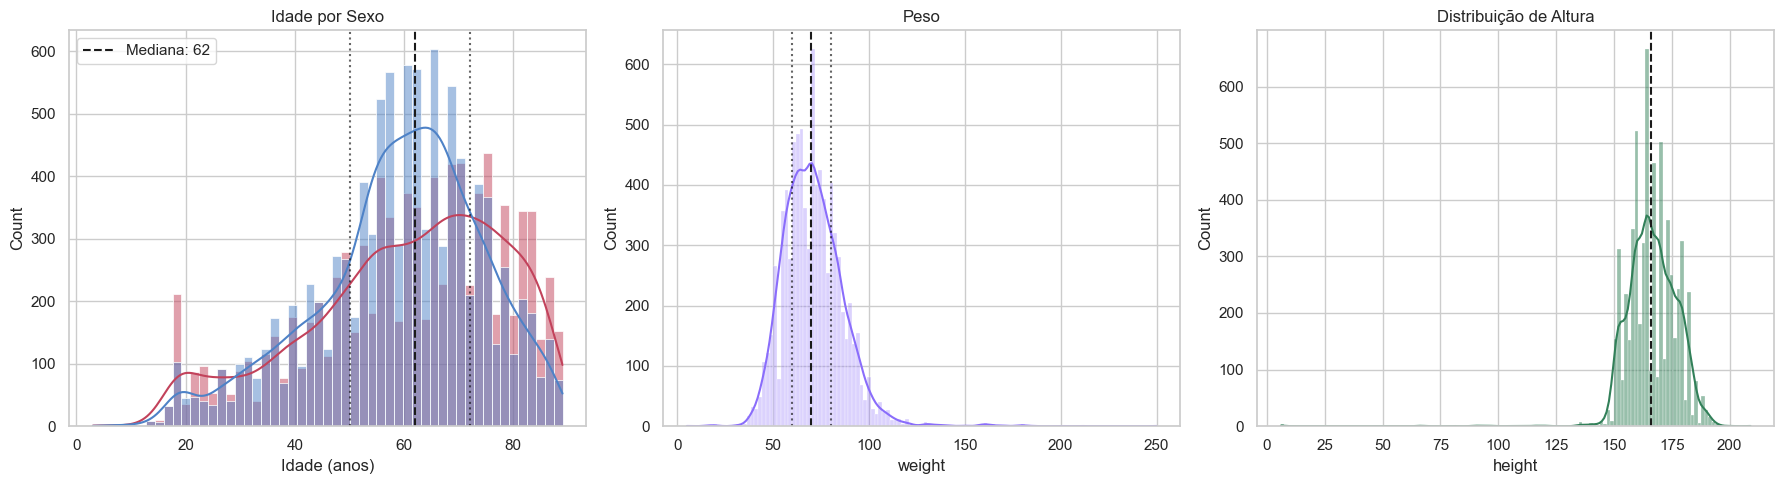

In [4]:
# Reanálise das Variáveis Demográficas

df['age_clean'] = df['age'].replace(300, np.nan)

vars_desc = ['age_clean', 'weight', 'height']
stats_demo = df[vars_desc].describe(percentiles=[0.05, 0.25, 0.75, 0.95]).T
stats_demo['IQR']       = stats_demo['75%'] - stats_demo['25%']
stats_demo['Variância'] = df[vars_desc].var()

display(Markdown("**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**"))
display(stats_demo.round(2))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='age_clean', hue='sex', kde=True,
             ax=axes[0], palette=['#4e82c7', '#c2425b'], alpha=0.5)
axes[0].axvline(df['age_clean'].median(), color='k', linestyle='--',
                label=f"Mediana: {df['age_clean'].median():.0f}")
axes[0].axvline(df['age_clean'].quantile(0.25), color='black', linestyle=':', alpha=0.6)
axes[0].axvline(df['age_clean'].quantile(0.75), color='black', linestyle=':', alpha=0.6)
axes[0].set_title('Idade por Sexo')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend()

sns.histplot(data=df, x='weight', color='#8a6dfb', kde = True, ax=axes[1], alpha = 0.3)
axes[1].axvline(df['weight'].median(), color='k', linestyle='--',
                label=f"Mediana: {df['weight'].median():.0f}")
axes[1].axvline(df['weight'].quantile(0.25), color='black', linestyle=':', alpha=0.6)
axes[1].axvline(df['weight'].quantile(0.75), color='black', linestyle=':', alpha=0.6)
axes[1].set_title('Peso')

sns.histplot(data=df, x='height', kde=True, ax=axes[2], color='#328059', alpha=0.5)
axes[2].axvline(df['height'].median(), color='k', linestyle='--')
axes[2].set_title('Distribuição de Altura')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'descritiva_demografica.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 1.1:**

Analisando a aparência dos gráficos acima e comparando-os aos gerados durante o Entregável 1, vemos que as alterações foram mínimas e localizadas em valores tão diversos que poderíamos dizer que, na prática, essas variáveis não sofreram impacto algum da exclusão dos sinais classificados como U: portanto, a análise anteriormente feita continuar válida. 

Podemos ver que outliers absurdos e completamente sem sentido (como o indivíduo de peso 5kg e o de altura 6cm) acabaram por passar pelo filtro do SQI, o que poderia ser um problema para análise de tendências por peso/altura: contudo, nosso foco até agora foi puramente ter sinais de ECG coerentes e valiosos para nosso futuro modelo de diagnóstico. Com isso, esses outliers podem continuar a serem aceitos por enquanto.

### 1.2 Variáveis Demográficas por Superclasse Diagnóstica

A análise anterior tratou o dataset como um todo. Aqui, estratificamos as mesmas variáveis demográficas pelas **5 superclasses diagnósticas** (NORM, MI, CD, STTC, HYP) para identificar padrões clínicos entre grupos.

Para evitar ambiguidade decorrente do caráter **multi-label** do PTB-XL (um registro pode pertencer a mais de uma superclasse), filtramos apenas os registros com **exatamente uma superclasse associada** (`n_superclasses == 1`). Dessa forma, garantimos que cada observação pertence de forma inequívoca a um único grupo diagnóstico, tornando a comparação entre grupos estatisticamente válida.

A visualização de boxplots sobrepostos permite identificar se existem diferenças sistemáticas de idade entre as patologias — o que seria esperado clinicamente, já que doenças como infarto do miocárdio (MI) e hipertrofia (HYP) costumam manifestar-se em faixas etárias mais avançadas.

In [5]:
# Função auxiliar para plotar os gráficos desejados

def plot_box_com_quartis(df, var, ylabel, titulo, filename):
    fig = plt.figure(figsize=(10, 6))

    ax = sns.boxplot(
        data=df,
        x='single_class',
        y=var,
        order=classes_target,
        hue='single_class',
        palette='Set2',
        legend=False
    )

    # Quartis
    quartis = df.groupby('single_class')[var].quantile([0.25, 0.5, 0.75]).unstack().reindex(classes_target)
 
    # Anotações
    for i, classe in enumerate(classes_target):
        if classe not in quartis.index:
            continue

        q1 = quartis.loc[classe, 0.25]
        med = quartis.loc[classe, 0.5]
        q3 = quartis.loc[classe, 0.75]

        x = i + 0.25

        ax.text(x, q1, f'Q1 ={q1:.1f}', ha='center', va='top', fontsize=8, fontweight='bold')
        ax.text(x, med, f'Med ={med:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(x, q3, f'Q3 ={q3:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.title(titulo)
    plt.xlabel('Superclasse')
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

**Estatísticas separadas por diagnóstico:**

age_clean                         weight                          \
                median  mean   std    Q1    Q3 median  mean   std    Q1    Q3   
single_class                                                                    
CD                65.5  63.7  15.7  55.0  75.0   70.0  71.7  15.1  62.0  80.0   
HYP               64.0  61.6  15.5  53.0  73.0   70.0  70.3  14.4  60.0  79.0   
MI                64.0  64.0  12.5  56.0  73.0   73.0  74.6  18.9  62.0  84.0   
NORM              54.0  52.2  17.2  40.0  65.0   70.0  71.2  14.9  60.0  80.0   
STTC              65.0  64.2  14.2  55.0  75.0   70.0  71.2  17.0  60.0  80.0   

             height                             
             median   mean   std     Q1     Q3  
single_class                                    
CD            168.0  167.3  12.5  160.0  175.0  
HYP           168.0  167.0  10.0  160.0  174.2  
MI            168.0  166.8  12.3  160.0  174.0  
NORM          166.0  166.9  10.6  160.0  174.0  
STTC          165.0  165.5   9.4  159.0  172.0

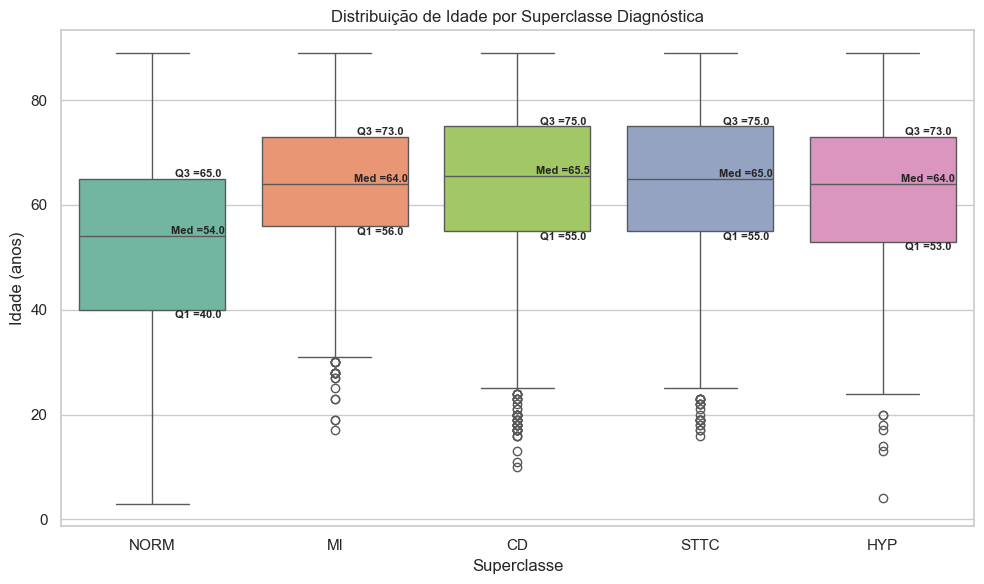

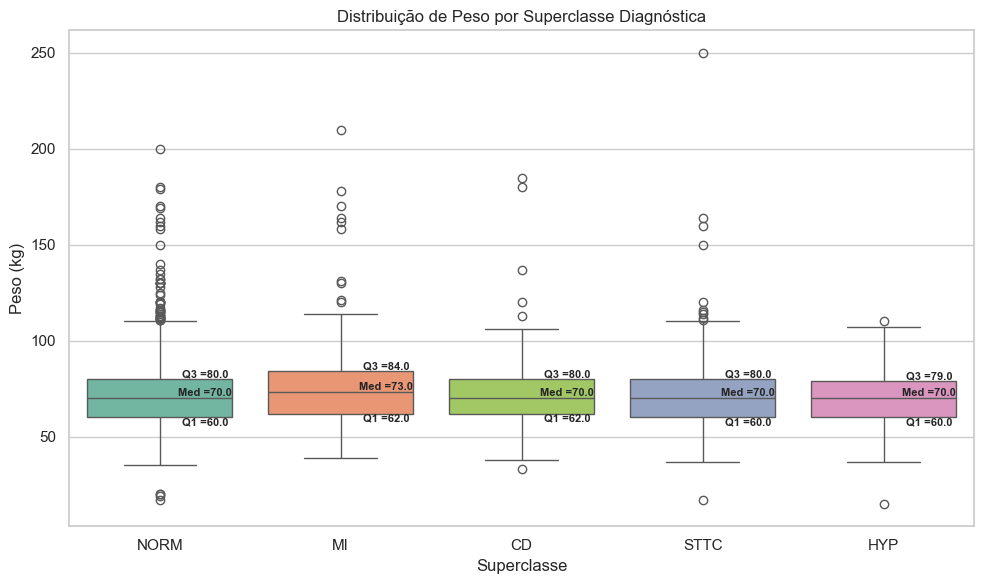

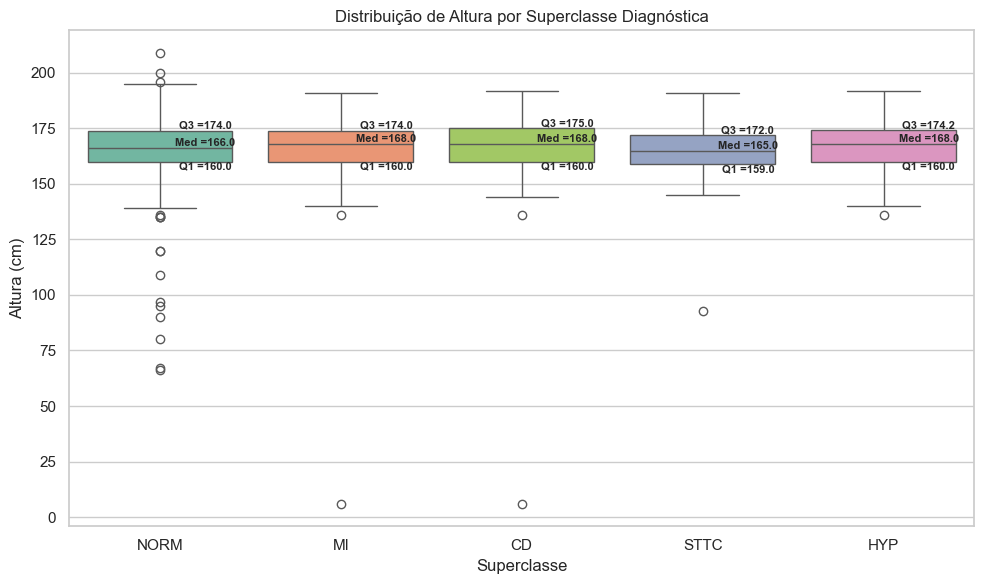

In [6]:
# Plot de Distribuição de Variáveis Demográficas por Superclasse Diagnóstica

df_single = df[df['n_superclasses'] == 1].copy()
df_single['single_class'] = df_single['superclasses_clean'].apply(lambda x: x[0])
classes_target = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

def Q1(x): return x.quantile(0.25)
def Q3(x): return x.quantile(0.75)

pivot_diag = df_single.groupby('single_class')[vars_desc].agg(['median', 'mean', 'std', Q1, Q3])
display(Markdown("**Estatísticas separadas por diagnóstico:**"))
display(pivot_diag.round(1))

plot_box_com_quartis(df_single,var='age_clean',ylabel='Idade (anos)',titulo='Distribuição de Idade por Superclasse Diagnóstica',filename='idade_por_superclasse.png')

plot_box_com_quartis(df_single,var='weight',ylabel='Peso (kg)',titulo='Distribuição de Peso por Superclasse Diagnóstica',filename='peso_por_superclasse.png')

plot_box_com_quartis(df_single,var='height',ylabel='Altura (cm)',titulo='Distribuição de Altura por Superclasse Diagnóstica',filename='altura_por_superclasse.png')

**Comentários sobre a subseção 1.2:**
A estratificação das variáveis demográficas por superclasse diagnóstica revela padrões consistentes, especialmente em relação à idade dos pacientes.

**Idade (age_clean):**
Observa-se uma diferença clara entre o grupo **NORM** e as demais superclasses. Enquanto pacientes classificados como NORM apresentam mediana de **54 anos** (Q1 = 40, Q3 = 65), as classes patológicas (**MI, CD, STTC e HYP**) concentram-se em faixas etárias mais elevadas, com medianas em torno de **64–65 anos**. Essa separação de aproximadamente 10 anos sugere um padrão consistente de associação entre envelhecimento e presença de alterações cardíacas, em linha com o conhecimento clínico sobre a progressão de doenças cardiovasculares.

**Peso (weight):**
As distribuições de peso são bastante semelhantes entre as classes, com medianas próximas de **70–73 kg**. A classe **MI** apresenta uma média ligeiramente superior (**74.6 kg**) e maior variabilidade (desvio padrão de 18.9), o que pode refletir maior heterogeneidade entre os pacientes desse grupo. No entanto, a elevada sobreposição entre as distribuições indica que o peso, isoladamente, possui baixo poder discriminativo entre as superclasses.

**Altura (height):**
As distribuições de altura são praticamente idênticas entre todos os grupos, com medianas entre **165 e 168 cm** e desvios padrão semelhantes. Não se observa qualquer tendência associada ao diagnóstico, sugerindo que essa variável não contribui de forma relevante para a distinção entre as superclasses.

**Síntese:**
De forma geral, a **idade** se destaca como a variável demográfica mais informativa, apresentando diferenças sistemáticas entre indivíduos saudáveis e pacientes com patologias cardíacas. Em contraste, **peso e altura** demonstram baixa capacidade discriminativa quando analisados isoladamente, embora possam adquirir relevância quando combinados em métricas derivadas, como o índice de massa corporal (IMC).


### 1.3 Distribuição Temporal dos Registros

O PTB-XL foi coletado ao longo de vários anos em contexto hospitalar. Analisar a evolução temporal dos registros é relevante por dois motivos:

1. **Representatividade ao longo do tempo:** um volume de coleta muito heterogêneo entre anos pode introduzir viés caso haja mudanças nas práticas clínicas ou nos equipamentos utilizados.
2. **Evolução do uso de laudos automáticos:** a proporção de laudos gerados automaticamente pelo equipamento (campo `initial_autogenerated_report`) em relação aos laudos manuais pode variar ao longo do tempo, refletindo a adoção crescente de tecnologias de análise automática de ECG.

O gráfico usa eixo duplo: barras para o volume de registros (eixo esquerdo) e linha para a taxa percentual de laudos automáticos (eixo direito).

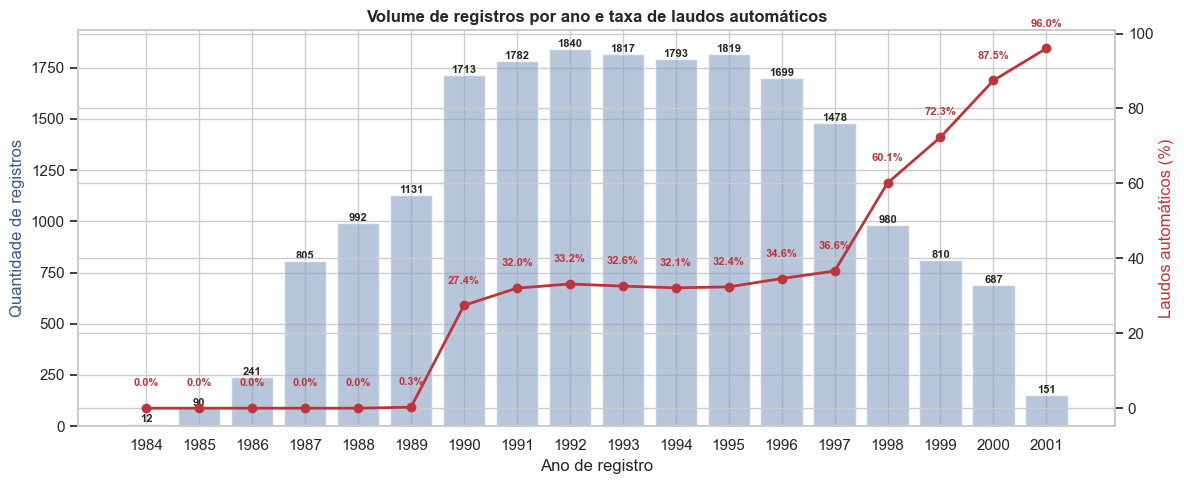

In [36]:
# Plot da análise de evolução temporal da coleta de registros

fig, ax1 = plt.subplots(figsize=(12, 5))

# -------------------------
# Preparar dados
# -------------------------
anos = df['recording_date'].dt.year
anos_range = range(int(anos.min()), int(anos.max()) + 1)

counts = anos.value_counts().sort_index().reindex(anos_range, fill_value=0)

# -------------------------
# Histograma (quantidade de registros)
# -------------------------
bars = ax1.bar(
    counts.index,
    counts.values,
    color='#8aa1c4',
    alpha=0.6
)

ax1.set_xlabel('Ano de registro')
ax1.set_ylabel('Quantidade de registros', color='#3a5c8c')
ax1.set_xticks(list(anos_range))  

# Anotações nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

# -------------------------
# Linha (% de laudos automáticos)
# -------------------------
ax2 = ax1.twinx()

taxa_auto = (
    df.groupby('recording_year')['initial_autogenerated_report']
    .mean()
    .reindex(anos_range) * 100
)

ax2.plot(
    taxa_auto.index,
    taxa_auto.values,
    color='#bd353a',
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Laudos automáticos (%)', color='#bd353a')

# Anotações na linha
y_range = ax2.get_ylim()[1] - ax2.get_ylim()[0]

for x, y in zip(taxa_auto.index, taxa_auto.values):
    if not np.isnan(y):
        ax2.text(
            x,
            y + 0.05 * y_range,  # 3% da escala do eixo
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#bd353a',
            fontweight='bold'
            
        )

# -------------------------
# Final
# -------------------------
plt.title('Volume de registros por ano e taxa de laudos automáticos', fontweight='bold')
plt.tight_layout()

fig.savefig(FIGS_DIR / 'temporal_coletas.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 1.3:**

A análise do gráfico temporal evidencia um crescimento acentuado no volume de registros de ECG ao longo do final da década de 1980 e, principalmente, durante os anos 1990. Esse aumento coincide com uma elevação expressiva na proporção de exames com laudos automatizados — por exemplo, observa-se um salto significativo entre 1989 e 1990, indicando a rápida incorporação de tecnologias computacionais no fluxo clínico.

Esse comportamento está fortemente associado à transição do ECG analógico para sistemas digitais baseados em computador, movimento impulsionado por avanços tecnológicos no período. Em particular, soluções desenvolvidas por empresas como *Nasiff Associates* tiveram papel relevante ao introduzir sistemas de aquisição de ECG de 12 derivações baseados em PC no final dos anos 1980. Essas tecnologias viabilizaram o armazenamento estruturado, a análise automatizada e a integração com sistemas clínicos, fatores essenciais para o aumento da escala de coleta e interpretação dos sinais.

Ao longo da década de 1990, observa-se um período de coleta intensiva e relativamente estável, com grande volume anual de registros. Esse comportamento é compatível com a fase de consolidação de infraestruturas digitais em ambientes clínicos, permitindo aquisição contínua, padronizada e em larga escala.

Por outro lado, a partir do final da década — especialmente próximo de 1998 — nota-se uma redução no volume de novos registros. Essa queda pode estar relacionada a múltiplos fatores, como a maturidade do banco de dados já estabelecido, mudanças nos protocolos de coleta, ou até mesmo transições institucionais e tecnológicas (por exemplo, migração de sistemas ou mudança de foco em iniciativas de pesquisa).

De forma geral, o gráfico reflete não apenas a evolução quantitativa da coleta de ECG, mas também uma mudança estrutural na forma como esses dados passaram a ser adquiridos, armazenados e analisados, marcando a transição para a era dos dados clínicos digitais.

---

**Referências externas:**

- Nasiff Associates — desenvolvimento de sistemas de ECG baseados em PC (final dos anos 1980):  
  https://nasiff.com/about-us/

- Integração de ECG com sistemas digitais e armazenamento clínico:  
  https://nasiff.com/cardiodatabase-system/

- Evolução da análise automatizada de ECG e digitalização de sinais biomédicos (contexto geral):  
  Clifford, G. D., Azuaje, F., & McSharry, P. (2006). *Advanced Methods and Tools for ECG Data Analysis*.

---
## Seção 2 — Estatística Descritiva dos Sinais

Até aqui analisamos apenas as variáveis nos **metadados** (demográficas e temporais). Nesta seção, passamos para os próprios **sinais de ECG**, calculando métricas de amplitude e energia por derivação e por superclasse diagnóstica.

Como processar todos os registros aprovados seria computacionalmente custoso, utilizamos uma **amostra estratificada**: 500 registros por superclasse (2500 no total), selecionados aleatoriamente dentre aqueles de:
- **Qualidade A** (alta qualidade SQI), para evitar que ruído interfira nas métricas de amplitude
- **Folds de treino** (1–8), para não contaminá-los com dados que serão usados exclusivamente para validação e teste

As métricas calculadas para cada registro e derivação são:
- **RMS (Root Mean Square):** raiz da média dos quadrados das amostras do sinal — representa a amplitude eficaz do ECG, análogo à tensão eficaz em circuitos elétricos. Um ECG com maior atividade elétrica cardíaca (ex: hipertrofia) terá RMS mais elevado.
- **Pico a pico (P2P):** diferença entre o máximo e o mínimo do sinal — captura a amplitude total de oscilação de cada derivação.
- **Energia total:** soma dos quadrados das amplitudes normalizada pela duração — quantifica o "conteúdo energético" global do registro.

### Função de Carregamento

A função `load_ecg` é reutilizada do Entregável 1 para carregar sinais individuais no formato WFDB a partir do seu `ecg_id`.

In [29]:
def load_ecg(ecg_id, dataframe, path_base, fs=100):
    """
    Carrega o sinal de ECG a partir dos arquivos WFDB do PTB-XL.

    Parâmetros:
    - ecg_id   : identificador do exame no dataframe
    - dataframe: tabela com os metadados (df)
    - path_base: caminho base onde estão os arquivos .dat/.hea
    - fs       : frequência de amostragem desejada (100 ou 500 Hz)

    Retorna:
    - signal_arr: array NumPy (n_amostras × 12 derivações) em milivolts
    """
    linha = dataframe.loc[ecg_id]
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']
    signal_arr, _ = wfdb.rdsamp(os.path.join(path_base, file_target))
    return signal_arr

# ──────────────────────────────────────────────
# Amostragem estratificada: 500 por superclasse
# ──────────────────────────────────────────────
df_a_puros = df_single[
    (df_single['quality_class'] == 'A') &
    (df_single['strat_fold'].isin(FOLDS_TREINO))
]

ids_amostra = []
for c in classes_target:
    pool = df_a_puros[df_a_puros['single_class'] == c]
    n = min(len(pool), 500)
    if n > 0:
        ids_amostra.extend(pool.sample(n, random_state=42).index)

display(Markdown(f"Carregando sinais de **{len(ids_amostra)}** registros amostrados (até 100 por superclasse)..."))

# ──────────────────────────────────────────────
# Loop de extração de métricas
# ──────────────────────────────────────────────
resultados_amp = []
energias       = []
cats           = []

for eid in tqdm(ids_amostra, desc='Extraindo métricas de amplitude'):
    sig  = load_ecg(eid, df, DATA_DIR, FS)
    cat  = df_single.loc[eid, 'single_class']

    s_rms = np.sqrt(np.mean(sig**2, axis=0))    # RMS por derivação
    s_p2p = np.max(sig, axis=0) - np.min(sig, axis=0)  # Pico-a-pico

    energias.append(np.sum(sig**2) / len(sig))  # Energia total normalizada
    cats.append(cat)

    for c_id, lead in enumerate(LEAD_NAMES):
        resultados_amp.append({
            'ecg_id': eid,
            'lead'  : lead,
            'class' : cat,
            'rms'   : s_rms[c_id],
            'p2p'   : s_p2p[c_id]
        })

df_amp   = pd.DataFrame(resultados_amp)
df_energ = pd.DataFrame({'ecg_id': ids_amostra, 'energia': energias, 'class': cats})

Carregando sinais de **2349** registros amostrados (até 100 por superclasse)...

Extraindo métricas de amplitude:   0%|          | 5/2349 [00:06<54:24,  1.39s/it]


KeyboardInterrupt: 

### 2.1 Amplitude RMS por Derivação e Superclasse

O heatmap de RMS mediano mostra, para cada combinação derivação × superclasse, o valor típico de amplitude eficaz em milivolts. Derivações com maior RMS indicam maior atividade elétrica naquela região cardíaca para aquela condição — isso tem interpretação anatômica direta.

Por exemplo:
- **Derivações precordiais V2–V5** costumam ter RMS elevado pois estão mais próximas ao músculo cardíaco e captam o complexo QRS com maior amplitude.
- **MI inferior** deve mostrar maior atividade em II, III e aVF (derivações que monitoram a parede inferior do coração, irrigada pela artéria coronária direita).
- **HYP (hipertrofia)** frequentemente apresenta amplitudes maiores em V5–V6 pela massa muscular aumentada do ventrículo esquerdo.

O boxplot de energia total por superclasse permite comparar a "intensidade elétrica global" entre os grupos diagnósticos, integrando a contribuição de todas as derivações.

In [ ]:
pivot_rms = df_amp.groupby(['lead', 'class'])['rms'].median().unstack()[classes_target]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_rms, annot=True, cmap='rocket', fmt=".3f", ax=ax1)
ax1.set_title('RMS Mediano por Derivação × Superclasse (mV)')
ax1.set_ylabel('Derivação')

sns.boxplot(data=df_energ, x='class', y='energia', order=classes_target, ax=ax2, palette='magma')
ax2.set_title('Energia Total por Superclasse')
ax2.set_ylabel('Energia (soma de amplitudes² / N)')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'rms_energia_superclasse.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.1:**

(conclusões dos gráficos)

---
## Seção 3 — Testes de Normalidade

A suposição de **normalidade** (distribuição gaussiana) é um pressuposto fundamental de muitos testes estatísticos clássicos, como ANOVA, teste t de Student e correlação de Pearson. Verificar formalmente essa suposição é indispensável para garantir que os testes aplicados nos entregáveis seguintes sejam estatisticamente válidos.

Em datasets grandes e biomédicos, a normalidade é frequentemente violada: variáveis como idade tendem a ser assimétrias (skewed) e métricas de sinal como amplitude RMS podem apresentar caudas pesadas pela presença de outliers clínicos.

Utilizamos dois testes complementares:

| Teste | Hipótese Nula (H₀) | Melhor para |
|---|---|---|
| **Shapiro-Wilk (SW)** | Dados seguem distribuição normal | Amostras pequenas (n < 5.000) — mais poderoso |
| **Kolmogorov-Smirnov (K-S)** | Dados seguem distribuição normal | Amostras grandes — mais conservador |

Em ambos os testes, **p < 0,05 leva à rejeição de H₀**, indicando que a distribuição não é normal com 95% de confiança.

### 3.1 Shapiro-Wilk e Kolmogorov-Smirnov

Aplicamos os dois testes em subamostras das variáveis de interesse, combinando variáveis de metadados e de sinal. O Shapiro-Wilk é executado com limite de 5.000 observações por restrição do algoritmo.

In [ ]:
amostra_v = df[['age_clean', 'weight', 'height']].dropna().sample(
    n=min(500, len(df)), random_state=42
)

vars_teste = {
    'Idade'       : amostra_v['age_clean'].values,
    'Peso'        : amostra_v['weight'].dropna().values,
    'Altura'      : amostra_v['height'].dropna().values,
    'RMS DII'     : df_amp[df_amp['lead'] == 'II']['rms'].values,
    'Energia total': df_energ['energia'].values
}

linhas_teste = []
for nome, valores in vars_teste.items():
    v = valores[~np.isnan(valores)]
    if len(v) < 3:
        continue

    # Shapiro-Wilk (limitado a 5.000 obs. pelo algoritmo)
    stat_sw, p_sw = stats.shapiro(v[:5000])

    # Kolmogorov-Smirnov contra distribuição normal com mesmos parâmetros
    stat_ks, p_ks = stats.kstest(v, 'norm', args=(np.mean(v), np.std(v)))

    linhas_teste.append({
        'Variável'                   : nome,
        'Shapiro W'                  : round(stat_sw, 4),
        'p (SW)'                     : "< 0.001" if p_sw < 0.001 else round(p_sw, 4),
        'Rejeita normalidade (SW)?'  : "Sim" if p_sw < 0.05 else "Não",
        'K-S stat'                   : round(stat_ks, 4),
        'p (K-S)'                    : "< 0.001" if p_ks < 0.001 else round(p_ks, 4),
        'Rejeita normalidade (K-S)?': "Sim" if p_ks < 0.05 else "Não"
    })

df_testes_norm = pd.DataFrame(linhas_teste).set_index('Variável')
display(Markdown("**Resultados dos testes de normalidade:**"))
display(df_testes_norm)

### 3.2 Q-Q Plots (Quantile-Quantile)

O Q-Q plot compara os quantis observados de uma variável com os quantis teóricos de uma distribuição normal. Se os pontos caem sobre a linha diagonal, a variável segue aproximadamente uma distribuição normal. **Desvios sistemáticos revelam o tipo de afastamento da normalidade:**

- **Curvatura em S:** distribuição com caudas mais pesadas (leptocúrtica) ou mais leves (platocúrtica) que a normal.
- **Desvio upward na cauda direita:** assimetria positiva (skewness > 0), típico de variáveis como peso ou RMS.
- **Desvio downward na cauda esquerda:** assimetria negativa.

In [ ]:
fig, axes = plt.subplots(1, len(vars_teste), figsize=(4 * len(vars_teste), 4))

for i, (nome, valores) in enumerate(vars_teste.items()):
    v = valores[~np.isnan(valores)]
    stats.probplot(v, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q: {nome}', fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle('Q-Q Plots: desvios da linha diagonal indicam afastamento da normalidade', fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 3.2:**

(conclusões dos gráficos)

---
## Seção 4 — Testes de Homocedasticidade

**Homocedasticidade** significa que a variância de uma variável é aproximadamente igual entre todos os grupos comparados. É o segundo pressuposto (após normalidade) dos testes paramétricos clássicos como ANOVA. Mesmo quando os dados não são normais, verificar homocedasticidade é importante pois:

- Indica se os grupos diferem não apenas em nível central (média/mediana) mas também em dispersão.
- Determina qual versão de cada teste utilizar (ex: ANOVA padrão vs. Welch ANOVA).

### 4.1 Levene e Bartlett

| Teste | Pressuposto | Característica |
|---|---|---|
| **Levene** (baseado na mediana) | Não assume normalidade | **Robusto** — preferido quando normalidade é rejeitada |
| **Bartlett** | Assume normalidade | Mais poderoso quando dados são normais; sensível a desvios |

Para ambos, **H₀: variâncias são iguais entre os grupos**. Se p < 0,05, rejeitamos H₀ e concluímos que as variâncias são heterogêneas (**heterocedasticidade**).

In [ ]:
grupos_idade = [df_single[df_single['single_class'] == c]['age_clean'].dropna()
                for c in classes_target]
grupos_energ = [df_energ[df_energ['class'] == c]['energia'].dropna()
                for c in classes_target]
grupos_rms   = [df_amp[(df_amp['lead'] == 'II') & (df_amp['class'] == c)]['rms'].dropna()
                for c in classes_target]

linhas_h = []
metricas_hetero = {
    'Idade'       : grupos_idade,
    'Energia total': grupos_energ,
    'RMS DII'     : grupos_rms
}

for nome, grupos in metricas_hetero.items():
    stat_l, p_l = stats.levene(*grupos, center='median')
    stat_b, p_b = stats.bartlett(*grupos)
    linhas_h.append({
        'Variável'                  : nome,
        'Levene stat'               : round(stat_l, 4),
        'Levene p-valor'            : "< 0.001" if p_l < 0.001 else round(p_l, 4),
        'Homocedástica (Levene)?'   : 'Não' if p_l < 0.05 else 'Sim',
        'Bartlett stat'             : round(stat_b, 4),
        'Bartlett p-valor'          : "< 0.001" if p_b < 0.001 else round(p_b, 4),
        'Homocedástica (Bartlett)?': 'Não' if p_b < 0.05 else 'Sim'
    })

df_hetero = pd.DataFrame(linhas_h).set_index('Variável')
display(Markdown("**Resultados dos testes de homocedasticidade:**"))
display(df_hetero)

**Comentários sobre a subseção 4.1:**

(conclusões dos gráficos)

### 4.2 Tabela-Decisão Metodológica

Com base nos resultados de normalidade (Seção 3) e homocedasticidade (Seção 4.1), geramos automaticamente a **tabela-decisão** que define quais testes estatísticos devem ser utilizados em cada variável nos entregáveis subsequentes.

A lógica é:
- **Dados normais + variâncias homogêneas →** testes paramétricos.
- **Dados não-normais ou variâncias heterogêneas →** testes não-paramétricos.

Os testes não-paramétricos são baseados em **ranks** (posições ordenadas) e não fazem suposições sobre a forma da distribuição, sendo adequados para dados biomédicos reais.

In [ ]:
linhas_decisao = []

for var in df_testes_norm.index:
    eh_normal = df_testes_norm.loc[var, 'Rejeita normalidade (SW)?'] == 'Não'

    if var in df_hetero.index:
        eh_homo = df_hetero.loc[var, 'Homocedástica (Levene)?'] == 'Sim'
    else:
        eh_homo = None

    str_normal = 'Sim' if eh_normal else 'Não'
    str_homo   = 'Sim' if eh_homo else ('A verificar' if eh_homo is None else 'Não')

    if eh_normal and (eh_homo is None or eh_homo):
        teste_k = 'ANOVA'
        teste_2 = 't-test'
    else:
        teste_k = 'Kruskal-Wallis'
        teste_2 = 'Mann-Whitney U'

    linhas_decisao.append({
        'Variável'          : var,
        'Normal?'           : str_normal,
        'Homocedástica?'    : str_homo,
        'Teste K grupos'    : teste_k,
        'Teste 2 grupos'    : teste_2
    })

df_decisao = pd.DataFrame(linhas_decisao).set_index('Variável')

display(Markdown("**Tabela-decisão gerada dinamicamente a partir dos testes:**"))
display(df_decisao)

# Conclusão automática
n_nao_normais = sum(1 for l in linhas_decisao if l['Normal?'] == 'Não')
total_vars    = len(linhas_decisao)

display(Markdown(
    f"**Conclusão:** {n_nao_normais} de {total_vars} variáveis rejeitaram normalidade.  \n"
    "Como a maioria não é normal e as variâncias diferem entre classes diagnósticas, "
    "**testes não-paramétricos (Kruskal-Wallis, Mann-Whitney U) devem ser adotados** "
    "em todas as comparações entre grupos nos entregáveis seguintes."
))

**Comentários sobre a subseção 4.2:**

(conclusões sobre os gráficos/tabelas)

---
## Seção 5 — Análise de Correlação

### 5.1 Matrizes de Pearson e Spearman

A análise de correlação revela o grau de **associação linear ou monotônica** entre pares de variáveis. Identificar correlações fortes é fundamental por dois motivos:

1. **Interpretação clínica:** correlações entre variáveis demográficas e métricas do sinal podem revelar padrões fisiológicos relevantes (ex: se idade se correlaciona com n_superclasses, isso confirma que pacientes mais velhos tendem a ter mais comorbidades).
2. **Engenharia de features:** variáveis muito correlacionadas entre si são redundantes. Incluir pares altamente correlacionados em modelos de machine learning pode introduzir multicolinearidade, inflando a variância dos coeficientes e dificultando a interpretação.

Utilizamos dois métodos complementares:

| Método | Detecta | Pressuposto |
|---|---|---|
| **Pearson** | Relações **lineares** | Normalidade (aproximada) |
| **Spearman** | Relações **monotônicas** (inclui não-lineares) | Nenhum — baseado em ranks |

Como os dados não seguem distribuição normal (confirmado na Seção 3), a correlação de **Spearman é mais confiável** neste contexto. A de Pearson é incluída para comparação. As matrizes são plotadas como **triângulos inferiores** para evitar redundância visual.

In [ ]:
df_corr_base = df[['age_clean', 'sex', 'weight', 'height', 'n_superclasses', 'sqi_score']].copy()

# Adicionando RMS pivotado dos registros amostrados
df_rms_pivot = df_amp.pivot(index='ecg_id', columns='lead', values='rms')
df_rms_pivot = df_rms_pivot.rename(columns={l: f'RMS_{l}' for l in LEAD_NAMES})

df_corr = df_corr_base.join(df_rms_pivot).join(df_energ.set_index('ecg_id')['energia'])

corr_p = df_corr.corr(method='pearson')
corr_s = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

mask = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, mask=mask, cmap='icefire', center=0,
            ax=axes[0], annot=False, cbar_kws={'shrink': .8})
axes[0].set_title('Pearson — Correlações Lineares', fontweight='bold')

sns.heatmap(corr_s, mask=mask, cmap='vlag', center=0,
            ax=axes[1], annot=False, cbar_kws={'shrink': .8})
axes[1].set_title('Spearman — Correlações Monotônicas', fontweight='bold')

plt.suptitle('Matrizes de Correlação: variáveis demográficas × métricas de sinal', fontsize=13)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'correlacoes_pearson_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 5.1:**

(conclusões sobre os gráficos)

---
## Seção 6 — Síntese e Conexão

Ao longo deste entregável, foi construído um panorama estatístico completo do dataset PTB-XL — após o filtro de qualidade do Entregável 2 — integrando análise descritiva de metadados, caracterização do sinal bruto, testes de hipótese formais e mapeamento de dependências entre variáveis.

### O que foi descoberto

**Perfil demográfico:** ...

**Amplitude e energia dos sinais:** ...

**Normalidade e homocedasticidade:** ...

**Correlações:** ...

---

### Decisão metodológica consolidada

...

---

### Conexão com o próximo entregável

Os resultados desta análise estabelecem a base metodológica para o **Entregável 4 (Limpeza e Correção dos Dados)**. O perfil estatístico aqui documentado — medianas, IQR e distribuição de amplitude por derivação — servirá como linha de base para a comparação obrigatória antes/depois da filtragem. Como todas as variáveis rejeitaram normalidade e homocedasticidade, a validação do efeito da limpeza deve utilizar **Wilcoxon signed-rank** em lugar do teste t pareado, e o effect size deve ser calculado com métricas robustas como a rank-biserial correlation. A tabela-decisão da Seção 4.2 permanece como referência sempre que uma comparação entre grupos for necessária nos entregáveis subsequentes.

Abaixo é salvo o .csv com os resultados obtidos nesse entregável:

In [ ]:
path_estat = OUT_DIR / 'estatistica_inicial_resultados.csv'

df_export = pd.concat([df_testes_norm, df_hetero], axis=1)
df_export.to_csv(path_estat)

display(Markdown(f"""
**Arquivo salvo:** `{path_estat}`

NameError: name 'df_testes_norm' is not defined